In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load the data
knn_df = pd.read_csv('insurance_fraud_data_processed.csv')
knn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9249 entries, 0 to 9248
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   claim_number        9249 non-null   int64  
 1   age_of_driver       9249 non-null   int64  
 2   gender              9249 non-null   object 
 3   marital_status      9249 non-null   int64  
 4   safety_rating       9249 non-null   int64  
 5   annual_income       9249 non-null   float64
 6   high_education      9249 non-null   int64  
 7   address_change      9249 non-null   int64  
 8   property_status     9249 non-null   object 
 9   zip_code            9249 non-null   int64  
 10  claim_date          9249 non-null   object 
 11  claim_day_of_week   9249 non-null   object 
 12  accident_site       9249 non-null   object 
 13  past_num_of_claims  9249 non-null   int64  
 14  witness_present     9249 non-null   float64
 15  liab_prct           9249 non-null   int64  
 16  channe

In [2]:
knn_df.describe()

,claim_number,age_of_driver,marital_status,safety_rating,annual_income,high_education,address_change,zip_code,past_num_of_claims,witness_present,liab_prct,police_report,age_of_vehicle,vehicle_price,total_claim,injury_claim,policy deductible,annual premium,days open,form defects
count,9.249000e+03,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000
mean,3.231217e+08,43.224781,0.715645,73.824305,60015.810540,0.697697,0.573359,49924.088226,0.485025,0.235701,49.706347,0.601795,4.971348,21920.101452,21687.848973,4888.299329,1010.325441,1268.943454,8.768534,3.956320
std,1.734202e+08,11.887665,0.451131,15.291783,4861.635116,0.459281,0.494616,29087.651958,0.941646,0.424459,33.467361,0.489555,2.225001,10461.063881,10460.030301,2021.933844,561.455096,229.598981,2.430818,1.977882
min,2.280960e+05,19.000000,0.000000,2.000000,45519.360000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2261.507903,2583.428985,547.029169,500.000000,653.660000,2.303305,0.000000
25%,1.789932e+08,34.000000,0.000000,66.000000,56884.800000,0.000000,0.000000,20112.000000,0.000000,0.000000,18.000000,0.000000,3.000000,13900.879610,13567.300360,3352.793086,500.000000,1082.360000,7.991217,3.000000
50%,3.177585e+08,43.000000,1.000000,77.000000,60185.600000,1.000000,1.000000,50028.000000,0.000000,0.000000,50.000000,1.000000,5.000000,20260.724040,19954.097450,4640.142346,1000.000000,1239.060000,9.263043,4.000000
75%,4.708524e+08,50.000000,1.000000,85.000000,63208.000000,1.000000,1.000000,80037.000000,1.000000,0.000000,81.000000,1.000000,6.000000,28525.420980,28218.722280,6198.491883,1000.000000,1383.490000,10.299194,5.000000
max,6.219556e+08,100.000000,1.000000,100.000000,76254.400000,1.000000,1.000000,85083.000000,6.000000,1.000000,100.000000,1.000000,14.000000,52124.564900,52156.424940,10701.051670,2000.000000,1829.630000,15.177169,13.000000


In [3]:
knn_df.isnull().sum()

claim_number          0
age_of_driver         0
gender                0
marital_status        0
safety_rating         0
annual_income         0
high_education        0
address_change        0
property_status       0
zip_code              0
claim_date            0
claim_day_of_week     0
accident_site         0
past_num_of_claims    0
witness_present       0
liab_prct             0
channel               0
police_report         0
age_of_vehicle        0
vehicle_category      0
vehicle_price         0
vehicle_color         0
total_claim           0
injury_claim          0
policy deductible     0
annual premium        0
days open             0
form defects          0
fraud reported        0
dtype: int64

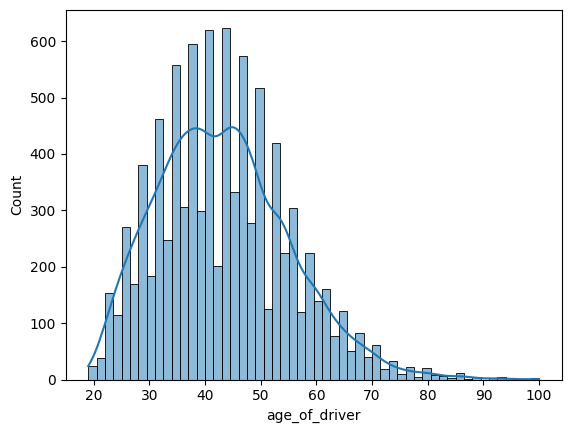

In [4]:
sns.histplot(knn_df['age_of_driver'], kde=True)
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Drop non-informative columns
drop_cols = ['claim_number', 'claim_date', 'zip_code']
knn_df_clean = knn_df.drop(columns=drop_cols)

# Encode the target
knn_df_clean['fraud reported'] = knn_df_clean['fraud reported'].map({'Y': 1, 'N': 0})

# Encode remaining categorical columns
cat_cols = knn_df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    knn_df_clean[col] = le.fit_transform(knn_df_clean[col].astype(str))

knn_df_clean.head()

Categorical columns to encode: ['gender', 'property_status', 'claim_day_of_week', 'accident_site', 'channel', 'vehicle_category', 'vehicle_color']


,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,claim_day_of_week,accident_site,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy deductible,annual premium,days open,form defects,fraud reported
0,39,1,1,73,58612.8,1,0,0,2,0,...,1,24360.59273,5,26633.27819,5196.552552,1000,1406.91,8.641800,5,0
1,53,0,1,93,73526.4,0,1,0,3,2,...,2,32910.34224,4,20909.27772,5671.599025,500,708.64,9.235943,4,0
2,41,1,1,87,59403.2,1,0,0,6,1,...,2,28570.37675,4,34493.97997,4064.569489,1000,1187.96,10.259629,2,0
3,49,0,0,57,62248.0,1,0,0,1,1,...,1,23264.32531,1,33770.80035,4264.395565,2000,1155.55,9.491945,5,0
4,70,1,1,58,67980.8,1,0,0,6,1,...,0,29214.53570,0,19172.68928,2417.922997,500,1451.62,7.454181,4,0


In [6]:
knn_df_clean['fraud reported'].value_counts()

fraud reported
0    6901
1    2348
Name: count, dtype: int64

In [7]:
from imblearn.over_sampling import SMOTE

X = knn_df_clean.drop(columns=['fraud reported'])
y = knn_df_clean['fraud reported']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

print(f"Training set (after SMOTE): {X_train_scaled.shape[0]} samples")
print(f"  - Not Fraud: {(y_train == 0).sum()}, Fraud: {(y_train == 1).sum()}")
print(f"Test set:     {X_test_scaled.shape[0]} samples")
print(f"Fraud rate (original): {y.mean():.2%}")

Training set (after SMOTE): 11042 samples
  - Not Fraud: 5521, Fraud: 5521
Test set:     1850 samples
Fraud rate (original): 25.39%


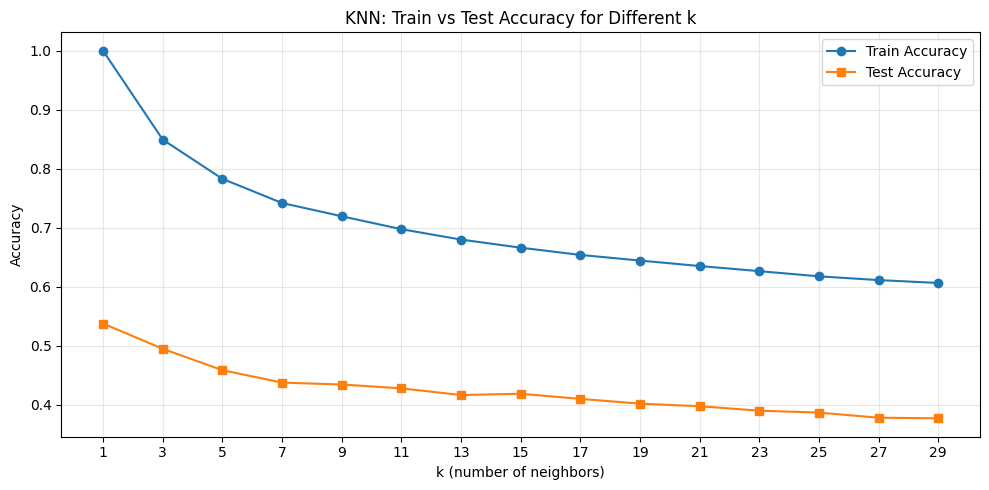


Best k = 1 with test accuracy = 0.5378


In [8]:
# Find the best k by evaluating odd values from 1 to 29
k_range = range(1, 31, 2)
train_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_scores, marker='o', label='Train Accuracy')
plt.plot(k_range, test_scores, marker='s', label='Test Accuracy')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Train vs Test Accuracy for Different k')
plt.xticks(list(k_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(test_scores)]
print(f"\nBest k = {best_k} with test accuracy = {max(test_scores):.4f}")

fraud reported
0    1380
1     470
Name: count, dtype: int64

KNN (k=1) — Classification Report

              precision    recall  f1-score   support

   Not Fraud       0.74      0.58      0.65      1380
       Fraud       0.25      0.41      0.31       470

    accuracy                           0.54      1850
   macro avg       0.50      0.50      0.48      1850
weighted avg       0.62      0.54      0.57      1850



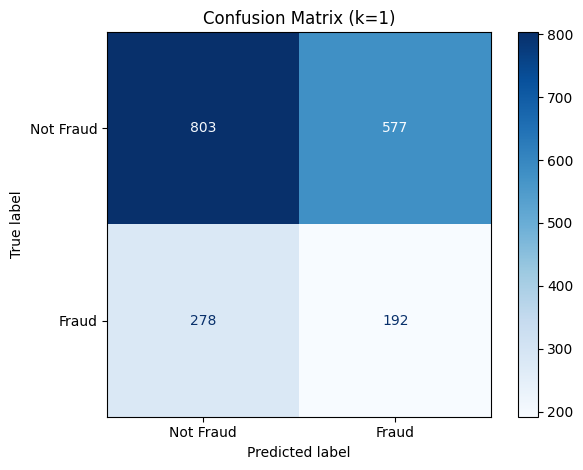

In [9]:
# Train the final model with the best k
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)
print(y_test.value_counts())
print()

print(f"KNN (k={best_k}) — Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (k={best_k})')
plt.tight_layout()
plt.show()

/Users/raymondip/opt/anaconda3/envs/my-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Training KNN: 100%|██████████| 100/100 [00:06<00:00, 16.59it/s]


KNN (k=1) — Results over 100 runs

      accuracy  precision    recall        f1  type_I_error  type_II_error
mean  0.556903   0.258152  0.397043  0.312830    536.340000     283.390000
std   0.010573   0.011467  0.019359  0.013936     16.506638       9.098668
min   0.534054   0.231198  0.344681  0.277635    498.000000     256.000000
max   0.579459   0.290761  0.455319  0.354892    579.000000     308.000000


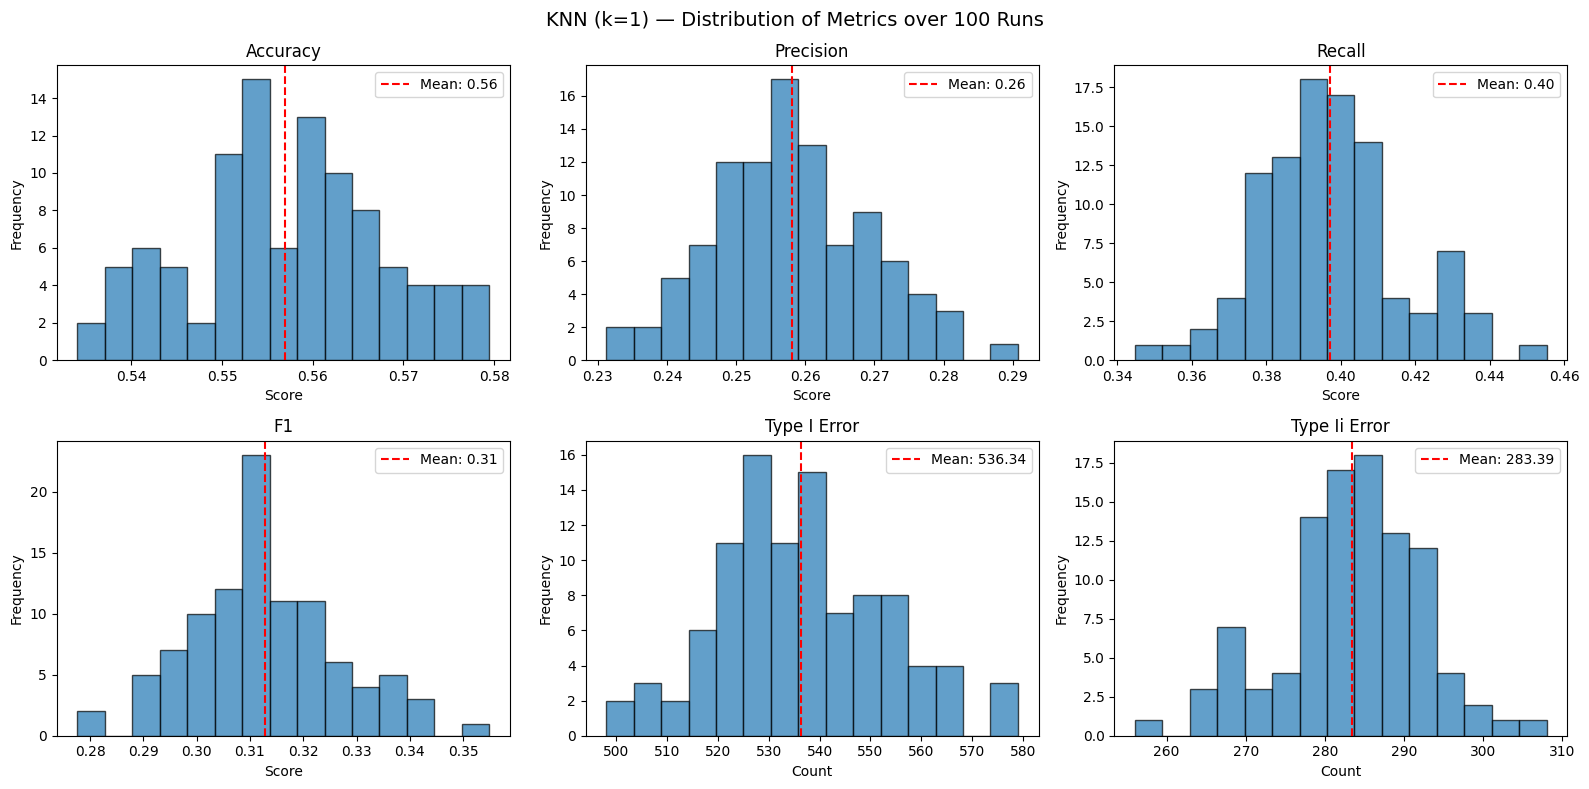

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.auto import tqdm

n_iterations = 100
results = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'type_I_error': [],
    'type_II_error': [],
}

X = knn_df_clean.drop(columns=['fraud reported'])
y = knn_df_clean['fraud reported']

for i in tqdm(range(n_iterations), desc="Training KNN", miniters=10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    smote = SMOTE(random_state=i)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_resampled, y_train_resampled)
    y_pred = knn.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results['accuracy'].append(accuracy_score(y_test, y_pred))
    results['precision'].append(precision_score(y_test, y_pred))
    results['recall'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['type_I_error'].append(fp)
    results['type_II_error'].append(fn)

results_df = pd.DataFrame(results)

print(f"KNN (k={best_k}) — Results over {n_iterations} runs\n")
print(results_df.describe().loc[['mean', 'std', 'min', 'max']].to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, metric in zip(axes.flatten(), results.keys()):
    ax.hist(results[metric], bins=15, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(results[metric]), color='red', linestyle='--',
               label=f'Mean: {np.mean(results[metric]):.2f}')
    title = metric.replace('_', ' ').title()
    ax.set_title(title)
    ax.set_xlabel('Count' if 'error' in metric else 'Score')
    ax.set_ylabel('Frequency')
    ax.legend()
fig.suptitle(f'KNN (k={best_k}) — Distribution of Metrics over {n_iterations} Runs', fontsize=14)
plt.tight_layout()
plt.show()

fraud reported
0    1380
1     470
Name: count, dtype: int64

KNN (k=5) with SMOTE — Classification Report

              precision    recall  f1-score   support

   Not Fraud       0.75      0.88      0.81      1380
       Fraud       0.26      0.12      0.16       470

    accuracy                           0.69      1850
   macro avg       0.50      0.50      0.49      1850
weighted avg       0.62      0.69      0.64      1850



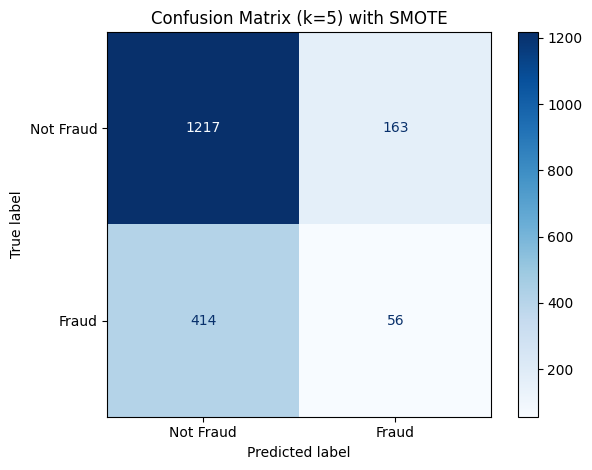

In [11]:
# Train the final model with k=5 (with SMOTE)
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)
print(y_test.value_counts())
print()

print(f"KNN (k=5) with SMOTE — Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (k=5) with SMOTE')
plt.tight_layout()
plt.show()

Training KNN: 100%|██████████| 100/100 [00:06<00:00, 15.77it/s]


KNN (k=5) — Results over 100 runs

      accuracy  precision    recall        f1  type_I_error  type_II_error
mean  0.471773   0.256578  0.568766  0.353594    774.540000     202.680000
std   0.010009   0.007290  0.020313  0.010338     18.142767       9.547203
min   0.449730   0.239733  0.519149  0.330887    725.000000     180.000000
max   0.500000   0.271739  0.617021  0.376379    816.000000     226.000000


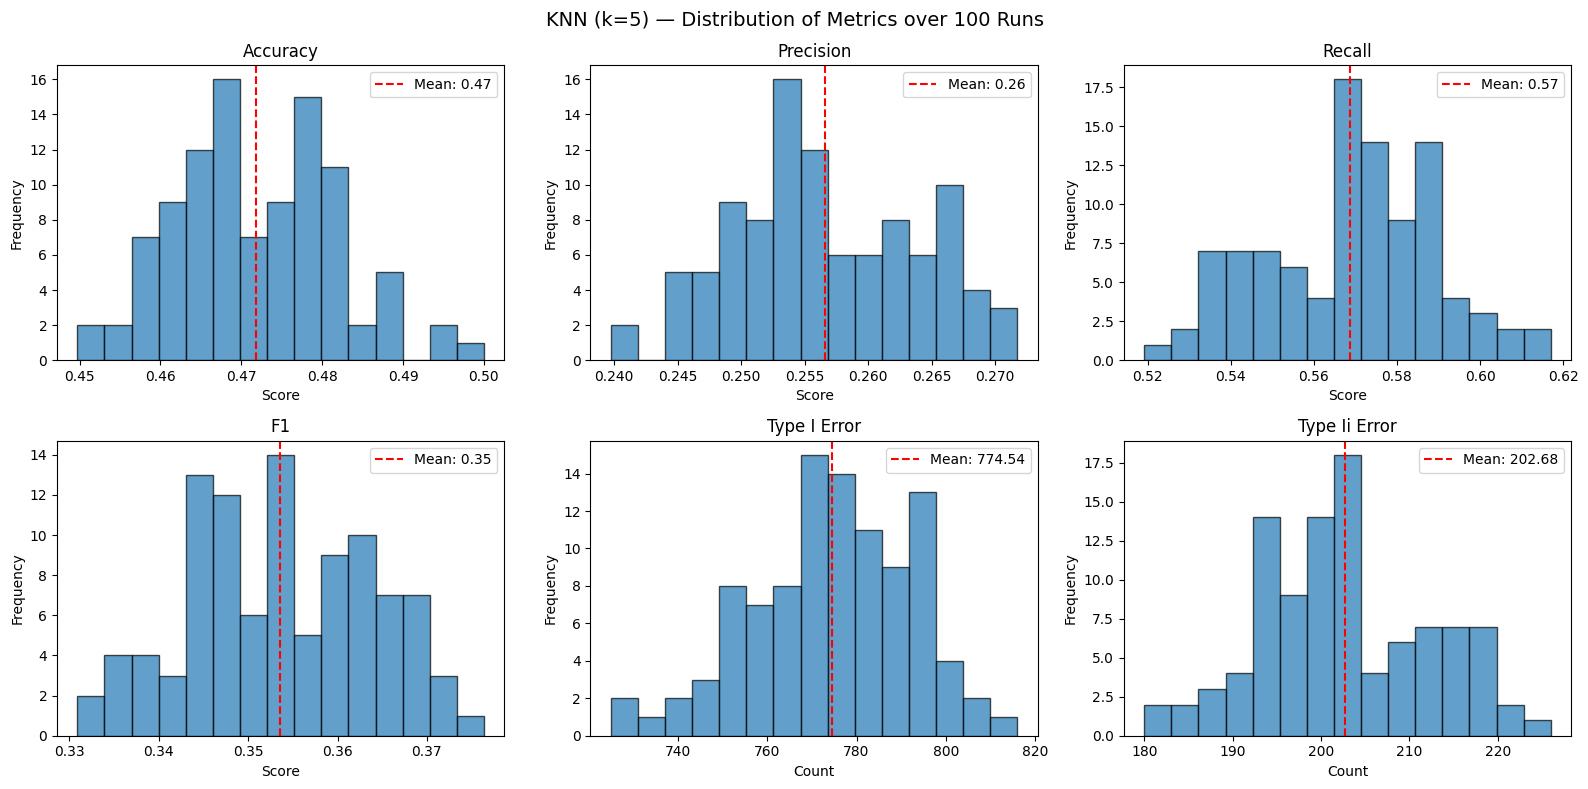

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.auto import tqdm

n_iterations = 100
results = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'type_I_error': [],
    'type_II_error': [],
}

X = knn_df_clean.drop(columns=['fraud reported'])
y = knn_df_clean['fraud reported']

for i in tqdm(range(n_iterations), desc="Training KNN", miniters=10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    smote = SMOTE(random_state=i)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_resampled, y_train_resampled)
    y_pred = knn.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results['accuracy'].append(accuracy_score(y_test, y_pred))
    results['precision'].append(precision_score(y_test, y_pred))
    results['recall'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['type_I_error'].append(fp)
    results['type_II_error'].append(fn)

results_df = pd.DataFrame(results)

print(f"KNN (k=5) — Results over {n_iterations} runs\n")
print(results_df.describe().loc[['mean', 'std', 'min', 'max']].to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, metric in zip(axes.flatten(), results.keys()):
    ax.hist(results[metric], bins=15, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(results[metric]), color='red', linestyle='--',
               label=f'Mean: {np.mean(results[metric]):.2f}')
    title = metric.replace('_', ' ').title()
    ax.set_title(title)
    ax.set_xlabel('Count' if 'error' in metric else 'Score')
    ax.set_ylabel('Frequency')
    ax.legend()
fig.suptitle(f'KNN (k=5) — Distribution of Metrics over {n_iterations} Runs', fontsize=14)
plt.tight_layout()
plt.show()